In [ ]:
from pyiron_workflow import Workflow
from pyiron import Project
from pyiron_atomistics import Atoms
import math
from rdflib import Namespace
from typing import Annotated
from semantikon import ontology as onto
from semantikon.metadata import meta
import matplotlib.pyplot as plt

In [2]:
ontology = Namespace("http://www.semanticweb.org/materials_science/")

In [3]:
@Workflow.wrap.as_function_node("Project")
def create_project(projectPath : Annotated[str, {"uri": ontology.ProjectPath}]) -> Annotated[Project, {"uri": ontology.Project}]:
    return Project(path=projectPath)

@Workflow.wrap.as_function_node("Structure")
def create_structure_bulk(project : Annotated[Project, {"uri": ontology.Project}]) -> Annotated[Atoms, {"uri": ontology.Structure}]:
    originalStructure = project.create.structure.bulk("FeAl", crystalstructure="cesiumchloride", a=2.9, cubic=True)
    originalStructure = originalStructure.repeat([2, 2, 2])
    return originalStructure

@Workflow.wrap.as_function_node("Structure")
def create_vacancy_Al(structure : Annotated[Atoms, {"uri": ontology.Structure}], position : Annotated[int, {"uri": ontology.Position}]) -> Annotated[Atoms, {"uri": ontology.Structure}]:
    vacancyAl = structure.copy()
    del vacancyAl[position]
    return vacancyAl

@Workflow.wrap.as_function_node("Structure")
def create_vacancy_Fe(structure : Annotated[Atoms, {"uri": ontology.Structure}], position : Annotated[int, {"uri": ontology.Position}]) -> Annotated[Atoms, {"uri": ontology.Structure}]:
    vacancyFe = structure.copy()
    del vacancyFe[position]
    return vacancyFe

@Workflow.wrap.as_function_node("Structure")
def create_antisite_Al(structure : Annotated[Atoms, {"uri": ontology.Structure}], position : Annotated[int, {"uri": ontology.Position}]) -> Annotated[Atoms, {"uri": ontology.Structure}]:
    antisiteAl = structure.copy()
    antisiteAl[position] = "Al"
    return antisiteAl

@Workflow.wrap.as_function_node("Structure")
def create_antisite_Fe(structure : Annotated[Atoms, {"uri": ontology.Structure}], position : Annotated[int, {"uri": ontology.Position}]) -> Annotated[Atoms, {"uri": ontology.Structure}]:
    antisiteFe = structure.copy()
    antisiteFe[position] = "Fe"
    return antisiteFe

@Workflow.wrap.as_function_node("Structure")
def relax_structure_gpaw(project : Annotated[Project, {"uri": ontology.Project}], structure : Annotated[Atoms, {"uri": ontology.Structure}], jobName : Annotated[str, {"uri": ontology.JobName}]) -> Annotated[Atoms, {"uri": ontology.Structure}]:
    relax_job = project.create.job.Gpaw(jobName, delete_existing_job=False)
    relax_job.structure = structure
    relax_job.calc_minimize()
    relax_job.run()
    relaxedStructure = relax_job.get_structure()
    return relaxedStructure

@Workflow.wrap.as_function_node("Structure")
def relax_structure_sphinx(project : Annotated[Project, {"uri": ontology.Project}], structure : Annotated[Atoms, {"uri": ontology.Structure}], jobName : Annotated[str, {"uri": ontology.JobName}]) -> Annotated[Atoms, {"uri": ontology.Structure}]:
    relax_job = project.create.job.Sphinx(jobName, delete_existing_job=False)
    relax_job.structure = structure
    relax_job.calc_minimize()
    relax_job.run()
    relaxedStructure = relax_job.get_structure()
    return relaxedStructure

@Workflow.wrap.as_function_node("Energy")
def run_gpaw(project : Annotated[Project, {"uri": ontology.Project}], structure : Annotated[Atoms, {"uri": ontology.Structure}], jobName : Annotated[str, {"uri": ontology.JobName}]) -> Annotated[float, {"uri": ontology.Energy}]:
    calc_energy_job = project.create.job.Gpaw(jobName, delete_existing_job=False)
    calc_energy_job.structure = structure
    calc_energy_job.run()
    energy = calc_energy_job.output.energy_tot[0]
    return energy

@Workflow.wrap.as_function_node("Energy")
def run_sphinx(project : Annotated[Project, {"uri": ontology.Project}], structure : Annotated[Atoms, {"uri": ontology.Structure}], jobName : Annotated[str, {"uri": ontology.JobName}]) -> Annotated[float, {"uri": ontology.Energy}]:
    calc_energy_job = project.create.job.Sphinx(jobName, delete_existing_job=False)
    calc_energy_job.structure = structure
    calc_energy_job.run()
    energy = calc_energy_job.output.energy_tot[0]
    return energy

@Workflow.wrap.as_function_node("ChemPotentialAl")
def calc_chem_pot_Al(project : Annotated[Project, {"uri": ontology.Project}], jobName : Annotated[str, {"uri": ontology.JobName}]) -> Annotated[float, {"uri": ontology.ChemicalPotential}]:
    bulk_Al = project.create.structure.bulk('Al', crystalstructure='fcc')
    calc_potential_job = project.create.job.Gpaw(jobName, delete_existing_job=True)
    calc_potential_job.structure = bulk_Al
    calc_potential_job.run()
    chemPotential = calc_potential_job.output.energy_tot[0]
    return chemPotential

@Workflow.wrap.as_function_node("ChemPotentialFe")
def calc_chem_pot_Fe(project : Annotated[Project, {"uri": ontology.Project}], jobName : Annotated[str, {"uri": ontology.JobName}]) -> Annotated[float, {"uri": ontology.ChemicalPotential}]:
    bulk_Fe = project.create.structure.bulk('Fe', crystalstructure='bcc')
    calc_potential_job = project.create.job.Gpaw(jobName, delete_existing_job=True)
    calc_potential_job.structure = bulk_Fe
    calc_potential_job.run()
    chemPotential = calc_potential_job.output.energy_tot[0]
    return chemPotential

@Workflow.wrap.as_function_node("DefectFormationEnergy")
def calculate_defect_formation_energy(energyDefect : Annotated[float, {"uri": ontology.Energy}], energyOriginal : Annotated[float, {"uri": ontology.Energy}], chemPotential : Annotated[float, {"uri": ontology.ChemicalPotential}]) -> Annotated[float, {"uri": ontology.DefectFormationEnergy}]:
    defectFormationEnergy = energyDefect - energyOriginal + chemPotential
    return defectFormationEnergy

@Workflow.wrap.as_function_node("DefectConcentration")
def calc_defect_concentration(defectFormationEnergy : Annotated[float, {"uri": ontology.DefectFormationEnergy}]) -> Annotated[float, {"uri": ontology.DefectConcentration}]:
    k_B = 0.0000862
    temp = 1000
    concentration_defect = math.exp(-defectFormationEnergy/(k_B * temp))
    return concentration_defect

@Workflow.wrap.as_function_node("AlConcentration")
def calc_Al_concentration(c_AlVac : Annotated[float, {"uri": ontology.DefectConcentration}], c_FeVac : Annotated[float, {"uri": ontology.DefectConcentration}]) -> Annotated[float, {"uri": ontology.AlConcentration}]:
    c_Al_AlVac = (1 - c_AlVac)/(2 - c_AlVac)
    c_Al_FeVac = 1/(2 - c_FeVac)
    c_Al = [c_Al_AlVac, c_Al_FeVac]
    return c_Al


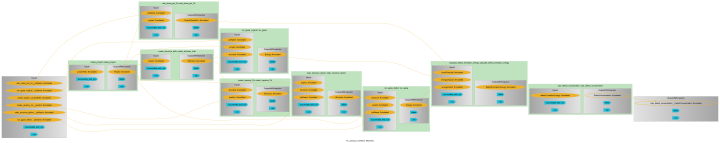

In [7]:
defect_wf = Workflow("Fe_vacancy_workflow")

defect_wf.create_project = create_project("Fe_vacancy_workflow")
defect_wf.create_structure_bulk = create_structure_bulk(project = defect_wf.create_project)
defect_wf.create_vacancy_Fe = create_vacancy_Fe(structure = defect_wf.create_structure_bulk, position = 0)
defect_wf.relax_structure_sphinx = relax_structure_sphinx(project = defect_wf.create_project, structure = defect_wf.create_vacancy_Fe, jobName = "relaxFeVac")
defect_wf.run_gpaw_original = run_gpaw(project = defect_wf.create_project, structure = defect_wf.create_structure_bulk, jobName = "calcEnergyOriginal2")
defect_wf.run_gpaw_defect = run_gpaw(project = defect_wf.create_project, structure = defect_wf.relax_structure_sphinx, jobName = "calcEnergyFeVac")
defect_wf.calc_chem_pot_Fe = calc_chem_pot_Fe(project = defect_wf.create_project, jobName = "calcChemPotFe")
defect_wf.calculate_defect_formation_energy = calculate_defect_formation_energy(energyDefect = defect_wf.run_gpaw_defect, energyOriginal = defect_wf.run_gpaw_original, chemPotential = defect_wf.calc_chem_pot_Fe)
defect_wf.calc_defect_concentration = calc_defect_concentration(defectFormationEnergy =  defect_wf.calculate_defect_formation_energy)

defect_wf.draw(size=(10,10))
